In [ ]:
import os
import cv2
import shutil
from sklearn.model_selection import train_test_split

def splitting_Data(dataset_root, root, test_size=0.2, validation_size=0.2):
    classes = os.listdir(dataset_root)
    print(classes)
    
    # Create directories for train, validation, and test data
    train_root = os.path.join(root, "train")
    validation_root = os.path.join(root, "validation")
    test_root = os.path.join(root, "test")
    
    for dir_path in [train_root, validation_root, test_root]:
        if not os.path.exists(dir_path):
            os.makedirs(dir_path)
    
    for class_name in classes:
        class_path = os.path.join(dataset_root, class_name)
        image_files = [file for file in os.listdir(class_path) if cv2.imread(os.path.join(class_path, file)) is not None]
        
        # Split the data into training and testing sets
        train_files, test_files = train_test_split(image_files, test_size=test_size, random_state=42)
        train_files, val_files = train_test_split(train_files, test_size=validation_size, random_state=42)
        
        
        train_class_dir = os.path.join(train_root, class_name)
        validation_class_dir = os.path.join(validation_root, class_name)
        test_class_dir = os.path.join(test_root, class_name)
        
        for dir_path in [train_class_dir, validation_class_dir, test_class_dir]:
            if not os.path.exists(dir_path):
                os.makedirs(dir_path)
        for file in train_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(train_class_dir, file))
        for file in val_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(validation_class_dir, file))
        for file in test_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(test_class_dir, file))
    
    print(f"Data has been successfully split into Train, Validation, and Test: {root}")

    
dataset_root=r"Dataset\NEW_DATA"
root="Dataset\Final Dataset Split"
if not os.path.exists(root):
    os.makedirs(root)
splitting_Data(dataset_root, root, test_size=0.2, validation_size=0.2)

['Aphids', 'Army worm', 'Bacterial Blight', 'Healthy']
Data has been successfully split into Train, Validation, and Test: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define paths to the datasets
train_dir = r"D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\train"
validation_dir = r"D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\validation"
test_dir = r"D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test"

# Set parameters
img_width, img_height = 256, 256
input_shape = (img_width, img_height, 3)
batch_size = 32
epochs = 10
# Define data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_width, img_height),
                                                    batch_size=batch_size, class_mode='categorical',
                                                    shuffle=True)

validation_generator = validation_test_datagen.flow_from_directory(validation_dir, target_size=(img_width, img_height),
                                                                  batch_size=batch_size, class_mode='categorical')


model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
history = model.fit(train_generator, steps_per_epoch=max(1, train_generator.samples // batch_size),
                    epochs=epochs, validation_data=validation_generator,
                    validation_steps=max(1, validation_generator.samples // batch_size),
                    callbacks=[reduce_lr])

# # Save the class indices to use for later predictions
# class_indices = train_generator.class_indices
# index_to_class = {v: k for k, v in class_indices.items()}

# # Evaluate on the test set
# test_generator = validation_test_datagen.flow_from_directory(test_dir, target_size=(img_width, img_height),
#                                                              batch_size=batch_size, class_mode='categorical', shuffle=False)

# # Make sure we predict on all images
# steps = test_generator.samples // batch_size + (test_generator.samples % batch_size > 0)
# predictions = model.predict(test_generator, steps=steps)

# # Convert predictions to class names
# predicted_classes_indices = np.argmax(predictions, axis=1)
# predicted_classes_names = [index_to_class[idx] for idx in predicted_classes_indices]

# # Output the predictions for each test image
# for i in range(len(predicted_classes_names)):
#     # Get the file path for the current index
#     file_path = test_generator.filepaths[i % len(test_generator.filepaths)]
#     print(f"Image: {file_path.split('/')[-1]} - Class: {predicted_classes_names[i]}")

# # Print the test accuracy
# test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
# print(f"Test Accuracy: {test_accuracy}")

Found 1328 images belonging to 4 classes.
Found 336 images belonging to 4 classes.
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 127, 127, 16)      0         
 ng2D)                                                           
                                                                 
 conv2d_11 (Conv2D)          (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 62, 62, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_12 (Conv2D)          (None, 60, 60, 64)        18496     
                                     

Epoch 88/90
41/41 [==============================] - 91s 2s/step - loss: 0.0654 - accuracy: 0.9776 - val_loss: 0.0811 - val_accuracy: 0.9781 - lr: 1.0000e-06
Epoch 89/90
41/41 [==============================] - 91s 2s/step - loss: 0.0629 - accuracy: 0.9799 - val_loss: 0.0818 - val_accuracy: 0.9781 - lr: 1.0000e-06
Epoch 90/90
41/41 [==============================] - 85s 2s/step - loss: 0.0643 - accuracy: 0.9769 - val_loss: 0.0697 - val_accuracy: 0.9844 - lr: 1.0000e-06


In [ ]:
class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

test_generator = validation_test_datagen.flow_from_directory(test_dir, target_size=(img_width, img_height),
                                                             batch_size=batch_size, class_mode='categorical', shuffle=False)

steps = test_generator.samples // batch_size + (test_generator.samples % batch_size > 0)
predictions = model.predict(test_generator, steps=steps)
predicted_classes_indices = np.argmax(predictions, axis=1)
predicted_classes_names = [index_to_class[idx] for idx in predicted_classes_indices]


for i in range(len(predicted_classes_names)):
    file_path = test_generator.filepaths[i % len(test_generator.filepaths)]
    print(f"Image: {file_path.split('/')[-1]} - Class: {predicted_classes_names[i]}")

test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f"Test Accuracy: {test_accuracy}")

Found 416 images belonging to 4 classes.
13/13 [==============================] - 12s 850ms/step
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\1.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\11.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\15.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\18.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\19.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\2.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\26.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\3.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\37.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\4.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\9.jpg - Class: Aphids
Image: D:\JUPYTER_NEW DATA\NEW_DATA\SPLIT\test\Aphids\constra

13/13 [==============================] - 8s 623ms/step - loss: 0.1308 - accuracy: 0.9712
Test Accuracy: 0.9711538553237915


In [9]:
for i, prediction in enumerate(predictions):
    print(f"Image {i}:")
    for class_index, conf in enumerate(prediction):
        class_name = index_to_class[class_index] 
        print(f"    {class_name}: {conf*100:.2f}%")
    print("\n")

Image 0:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 1:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 2:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 3:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 4:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 5:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 6:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 7:
    Aphids: 99.93%
    Army worm: 0.06%
    Bacterial Blight: 0.01%
    Healthy: 0.00%


Image 8:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 9:
    Aphids: 100.00%
    Army worm: 0.00%
    Bacterial Blight: 0.00%
    Healthy: 0.00%


Image 10:
 

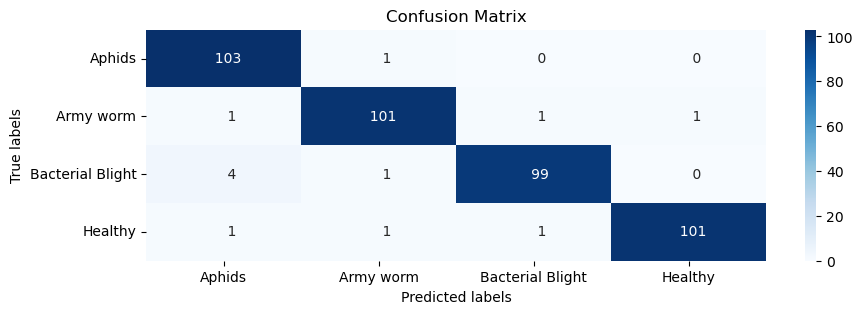

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes_indices)

class_names = [index_to_class[i] for i in range(len(index_to_class))]

plt.figure(figsize=(10, 3))
sns.heatmap(cm, annot=True, fmt='5', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


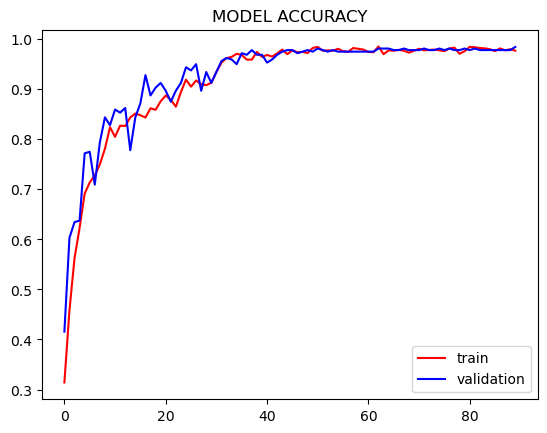

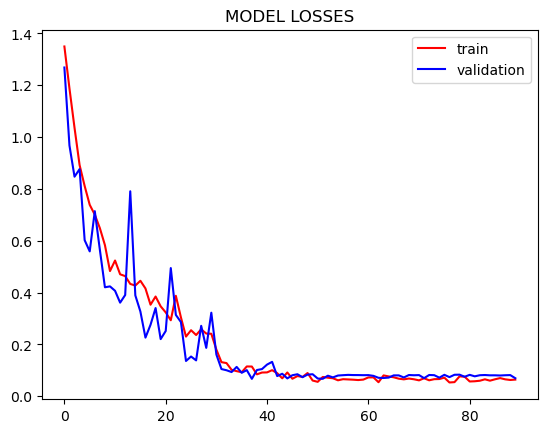

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.title('MODEL ACCURACY')
plt.legend()
plt.show()
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.title('MODEL LOSSES')
plt.legend()
plt.show()

In [16]:
model.save('FINAL_COTTON_97.11.h5')

C:\Users\PMLS\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [19]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model('FINAL_COTTON_97.11.h5')  
Class_label=['Aphids', 'Army worm', 'Bacterial Blight', 'Healthy']
def preprocess_image(image):
    resized_image = cv2.resize(image, (256, 256))
    preprocessed_image = resized_image.astype('float32') / 255.0
    preprocessed_image = np.expand_dims(preprocessed_image, axis=0)
    return preprocessed_image


def predict_image(image):
    preprocessed_image = preprocess_image(image)
    predictions = model.predict(preprocessed_image)
    return predictions

image_path = r"C:\Users\PMLS\Downloads\123.jfif"
# image_path = r"C:\Users\PMLS\Desktop\FYP PROGRESS 2\cotton DATA SET FINAL\split\test\curl_virus\curl01.jpg"
image = cv2.imread(image_path)


if image is not None:
    predictions = predict_image(image)
    label=Class_label[np.argmax(predictions)]
    print(label)
else:
    print("Failed to load image.")


1/1 [==============================] - 0s 195ms/step
Aphids


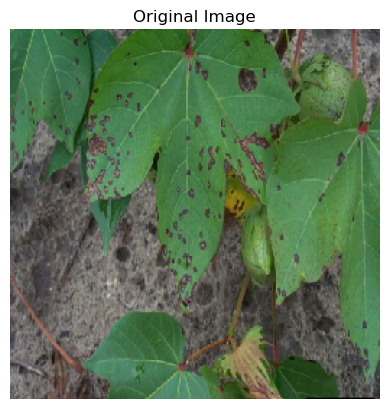

TypeError: path should be path-like or io.BytesIO, not <class 'numpy.ndarray'>

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import load_model

import cv2
import numpy as np

def preprocess_image(image_path):
    # Load the image using OpenCV (cv2)
    image = cv2.imread(image_path)
    
    # Check if the image is loaded successfully
    if image is None:
        print("Error: Unable to load the image.")
        return None
    
    # Resize the image to (256, 256)
    resized_image = cv2.resize(image, (256, 256))
    
    # Convert the image to float32 and normalize it
    preprocessed_image = resized_image.astype('float32') / 255.0
    
    # Add a dimension to the image array
    preprocessed_image = np.expand_dims(preprocessed_image, axis=0)
    
    return preprocessed_image



def plot_conv_layer_activations(model, image_path):
    # Load and preprocess the image
    img = keras_image.load_img(image_path, target_size=(256, 256))
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Extract feature maps from convolutional layers
    layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
    activation_model = Model(inputs=model.input, outputs=layer_outputs)
    activations = activation_model.predict(img_array)

    # Plot the activations for each convolutional layer
    for layer_activation, layer_name in zip(activations, [layer.name for layer in model.layers if 'conv' in layer.name]):
        num_filters = layer_activation.shape[-1]
        display_grid = np.zeros((num_filters // 8, 8, 254, 254))  # Adjust grid size
        for i in range(num_filters):
            channel_image = layer_activation[0, :, :, i]
            display_grid[i // 8, i % 8] = channel_image  # Assign channel image to display grid
        scale = 1. / num_filters
        plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
        plt.title(layer_name)
        plt.grid(False)
        for i in range(num_filters):
            plt.subplot(num_filters // 8, 8, i + 1)  # Adjust subplot index
            plt.imshow(display_grid[i // 8, i % 8], aspect='auto', cmap='viridis')
            plt.axis('off')
    plt.show()
    
image_path = r"C:\Users\PMLS\Downloads\Bacterial_Blight_Figure_1.jfif"
image=preprocess_image(image_path)
plot_original_image(image_path)
model = load_model('FINAL_COTTON_97.11.h5') 
plot_conv_layer_activations(model, image)


Image preprocessed successfully.
